# The Cat-in-the-Hat Problem: Why Insurers Under-Reserve for Correlated Climate Losses

### A self-contained lab report — synthetic data, real math, reproducible by anyone

**TL;DR:** We built a synthetic catastrophe-insurance "world" with a known, checkable
ground truth for tail dependence, then asked: if you only get to see a realistic slice
of historical data, how badly do the correlation shortcuts real capital models actually
use (independence, a flat correlation number) under-reserve, compared to a model that
represents the true loss-generating mechanism? And can a smarter fitting procedure close
that gap without more data?

**Headline findings**, all reproducible from the math in this notebook:

1. **Every correlation-blind method sits on a hard ceiling around 93.3% achieved survival**
   (vs. a 99.5% target), *no matter how much historical data it gets*. More data does not
   fix a model that structurally cannot represent the thing that matters.
2. A model that represents the *right mechanism class* (a hidden systemic-vs-normal
   regime) can close that gap — but only if it's *fit correctly*. A plausible-looking but
   naive implementation failed for a completely different, fixable reason.
3. Once fixed, a **soft (responsibility-weighted) classifier** — using every data point
   a little, instead of hard-assigning each year to one regime or the other — closes
   **almost the entire remaining gap**, at every data size tested, at both a small
   illustrative scale (500 properties) and a realistic book size (45,000 properties).

This notebook derives every method from its underlying math, verifies the synthetic
world actually has the tail-dependence property it claims to, and reproduces every
headline chart from the lab's own experimental results (loaded from this repository's
`results_*.json` files — the raw output of the experiments, not recomputed for this
write-up).

In [1]:
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

DATA_DIR = Path(".")

# --- Validated categorical palette (dataviz skill reference palette) -------
# Fixed hue order -- never cycled/reassigned. Slots 1-4 are the ones used
# for the four-method ladder throughout this notebook.
BLUE    = "#2a78d6"   # slot 1 -- method 1 (independence)
GREEN   = "#008300"   # slot 2 -- method 2 (flat correlation)
MAGENTA = "#e87ba4"   # slot 3 -- method 3 (vanilla spatial GP)
YELLOW  = "#eda100"   # slot 4 -- method 4, hard-partition classifier
AQUA    = "#1baf7a"   # slot 5 -- method 4, soft classifier
VIOLET  = "#4a3aa7"   # slot 7 -- oracle-cheat ceiling
RED     = "#e34948"   # diverging pole / systemic-year contrast
GRAY    = "#898781"   # muted ink -- gridlines, secondary annotations

INK        = "#0b0b0b"
INK_SECOND = "#52514e"
SURFACE    = "#fcfcfb"
GRID       = "#e1e0d9"
BASELINE   = "#c3c2b7"

plt.rcParams.update({
    "figure.facecolor": SURFACE,
    "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE,
    "axes.labelcolor": INK_SECOND,
    "text.color": INK,
    "xtick.color": INK_SECOND,
    "ytick.color": INK_SECOND,
    "grid.color": GRID,
    "font.size": 11,
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

METHOD_COLORS = {
    "1_independence": BLUE,
    "2_flat_correlation": GREEN,
    "3_vanilla_gp": MAGENTA,
    "4_gp_regime_mixture": YELLOW,
    "4_soft": AQUA,
}
METHOD_LABELS = {
    "1_independence": "1. Independence",
    "2_flat_correlation": "2. Flat correlation",
    "3_vanilla_gp": "3. Vanilla spatial GP",
    "4_gp_regime_mixture": "4. GP + regime mixture (hard)",
    "4_soft": "4. GP + regime mixture (soft)",
}


def pct_axis(ax):
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))


def load(name):
    with open(DATA_DIR / name) as f:
        return json.load(f)

## 1. The problem: sizing capital when losses are correlated

An insurer holding $n$ properties in a hurricane/wildfire-exposed region needs to decide
how much capital $C$ to hold so that, with probability $\alpha$ (e.g. 99.5%, the Solvency
II one-year Solvency Capital Requirement convention), next year's total losses
$L = \sum_{i=1}^n L_i$ don't exceed $C$:

$$
C^\star = \mathrm{VaR}_\alpha(L) = \inf\{c : P(L \le c) \ge \alpha\}
$$

If the $L_i$ were independent, the Central Limit Theorem makes $L$'s distribution
thin-tailed and $C^\star$ modest relative to $n \cdot \mathbb{E}[L_i]$. Real catastrophe
losses are **not independent** — a hurricane or wildfire season hits many properties in a
region simultaneously. Three ways an insurer might account for this, in increasing order
of sophistication, are the first three methods below; the fourth represents the
mechanism *directly*.

The catch: real capital models are fit on a **finite historical window** — 25-60 years of
company loss history is typical — while the tail event that determines $C^\star$ might
occur only once every 10-15 years. This notebook asks: given only that thin slice of
history, how badly does each method's *estimate* of $C^\star$ diverge from the *true*
$C^\star$?

## 2. A synthetic world with known, checkable tail dependence

To answer that question at all, we need a data-generating process (DGP) whose *true*
$C^\star$ is knowable (by resampling it directly — a luxury no real insurer has) and whose
tail-dependence mechanism is *explicit*, not assumed.

**The exposure book.** $n$ properties are scattered over a synthetic coastal region
(2°×3° of lat/lon), each with an insured value $V_i$ (lognormal, mean \$350k, matching
published U.S. dwelling-value benchmarks) and a baseline annual expected loss ratio
$\mu_i$ that increases smoothly toward the "coastal" edge of the region (a stand-in for
real hazard geography — storm surge, wildfire-urban-interface proximity, etc.).

**The regime.** Each year $t$ is either **normal** or **systemic** (a correlated
climate-extreme year — elevated regional drought/heat/wildfire-season conditions),
independently:

$$
R_t \sim \mathrm{Bernoulli}(p_{\text{sys}}), \qquad p_{\text{sys}} = \tfrac{1}{15}
$$

**The loss mechanism**, conditional on the regime. In a **normal** year, each property's
loss ratio is an independent lognormal draw around its own $\mu_i$ — no cross-property
structure. In a **systemic** year, a shared, spatially-correlated random field
$z(\cdot)$ over the region's geography multiplies *every* property's severity
simultaneously — nearby properties move together, distant ones don't — **and** the whole
year's severity is elevated by a fixed multiplier $m_{\text{sys}} = 6$:

$$
\frac{L_{i,t}}{V_i} = \mu_i \cdot \big(m_{\text{sys}}\big)^{R_t} \cdot
\exp\!\Big(\epsilon_{i,t} - \tfrac{\sigma_\epsilon^2}{2} + R_t \cdot z_i(t)\Big),
\qquad \epsilon_{i,t} \sim \mathcal{N}(0, \sigma_\epsilon^2)
$$

where $z(t) = (z_1(t), \dots, z_n(t))$ is drawn fresh each systemic year from
$\mathcal{N}(0, K)$ with $K_{ij} = \sigma_z^2 \exp\!\big({-\tfrac{1}{2}}
\|\mathbf{x}_i - \mathbf{x}_j\|^2/\ell^2\big)$ — a squared-exponential (RBF) kernel over
lat/lon, length scale $\ell = 0.5°$.

This is genuinely a two-regime **Gaussian process mixture**: no fitted method in this lab
ever sees $R_t$, $z(t)$, or any of these parameters — only a finite sample of realized
dollar losses. Every calibration constant here is illustrative (chosen to produce a real,
checkable tail-dependence effect — verified below — not a claim about any real peril's
true statistics).

In [2]:
# A compact, from-scratch reimplementation of the DGP above (written directly
# from the math, NOT importing the lab's own modules) -- self-contained
# enough to regenerate everything that follows from just this cell + numpy.

def rbf_kernel(coords, length_scale, variance):
    d2 = ((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1)
    return variance * np.exp(-0.5 * d2 / length_scale ** 2)


def build_book(n, seed=0):
    rng = np.random.default_rng(seed)
    lat = rng.uniform(25.0, 27.0, size=n)
    lon = rng.uniform(-82.0, -79.0, size=n)
    coastal = (lon - (-82.0)) / 3.0
    mu = 0.0015 * (1.0 + 3.0 * coastal)          # baseline loss ratio, coast-driven
    sigma_log = np.sqrt(np.log(1.0 + 0.4 ** 2))
    mu_log = np.log(350_000.0) - 0.5 * sigma_log ** 2
    V = rng.lognormal(mu_log, sigma_log, size=n)
    return dict(lat=lat, lon=lon, mu=mu, V=V, n=n)


def sample_losses(book, n_years, seed=0, p_sys=1 / 15, m_sys=6.0, sigma_eps=0.5,
                   ell=0.5, sigma_z=0.9):
    rng = np.random.default_rng(seed)
    n = book["n"]
    coords = np.stack([book["lat"], book["lon"]], axis=1)
    K = rbf_kernel(coords, ell, sigma_z ** 2)
    L = np.linalg.cholesky(K + 1e-9 * np.eye(n))

    regime = rng.random(n_years) < p_sys
    eps = rng.normal(0.0, sigma_eps, size=(n_years, n))
    z = np.zeros((n_years, n))
    n_sys = int(regime.sum())
    if n_sys > 0:
        z[regime] = rng.standard_normal((n_sys, n)) @ L.T

    log_ratio = eps - 0.5 * sigma_eps ** 2
    mult = np.where(regime[:, None], m_sys, 1.0)
    loss_ratio = book["mu"][None, :] * mult * np.exp(log_ratio + z)
    return loss_ratio * book["V"][None, :], regime


book = build_book(500, seed=0)
losses, regime = sample_losses(book, n_years=20_000, seed=1)
print(f"{regime.sum()} systemic years out of {len(regime)} "
      f"({regime.mean():.1%}, target {1/15:.1%})")

1364 systemic years out of 20000 (6.8%, target 6.7%)


## 3. Checking the DGP actually has the property it claims

Before trusting any downstream result, we verify the synthetic world has genuine,
checkable tail dependence — not just correlated on average, but specifically
**more correlated in the tail** than a Gaussian copula with the same marginal
correlation would produce (the textbook failure mode of naive multivariate-normal
catastrophe models).

**Metric: the upper tail-dependence coefficient.** For two properties $i, j$,

$$
\lambda_U = \lim_{q \to 1} P\big(F_i(L_i) > q \mid F_j(L_j) > q\big)
$$

— informally, "given property $j$ had an extreme year, how much more likely is property
$i$ to have also had one?" Independence gives $\lambda_U = 1-q$ (here, at $q=0.99$, a
baseline of exactly 1%). A Gaussian copula with the same *linear* correlation famously
gives $\lambda_U \to 0$ as $q \to 1$ (**tail independence**, regardless of the
correlation number) — a well-documented reason Gaussian-copula-based models can
under-price correlated tail risk. Our DGP, by construction, should show substantial
*excess* tail dependence, and should show it decay with distance (nearby pairs more
tail-dependent than far pairs) — both checked directly below.

In [3]:
def pair_stats(losses, regime, book, near_pairs=3000, far_pairs=3000, seed=0):
    rng = np.random.default_rng(seed)
    n = book["n"]
    coords = np.stack([book["lat"], book["lon"]], axis=1)
    d = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(-1))
    near_thresh, far_thresh = np.percentile(d[d > 0], [10, 90])

    i_idx, j_idx = np.triu_indices(n, k=1)
    dij = d[i_idx, j_idx]
    near_mask, far_mask = dij <= near_thresh, dij >= far_thresh

    def sample_pairs(mask, k):
        idx = np.where(mask)[0]
        pick = rng.choice(idx, size=min(k, len(idx)), replace=False)
        return i_idx[pick], j_idx[pick]

    ni, nj = sample_pairs(near_mask, near_pairs)
    fi, fj = sample_pairs(far_mask, far_pairs)

    def corr_in(mask_years, ii, jj):
        Ls = losses[mask_years]
        return np.mean([np.corrcoef(Ls[:, a], Ls[:, b])[0, 1] for a, b in zip(ii, jj)])

    corr_near_normal = corr_in(~regime, ni, nj)
    corr_near_systemic = corr_in(regime, ni, nj)

    def tail_dep(ii, jj, q=0.99):
        exceed = []
        for a, b in zip(ii, jj):
            ta = losses[:, a] > np.quantile(losses[:, a], q)
            tb = losses[:, b] > np.quantile(losses[:, b], q)
            exceed.append((ta & tb).sum() / max(tb.sum(), 1))
        return float(np.mean(exceed))

    return dict(corr_near_normal=corr_near_normal, corr_near_systemic=corr_near_systemic,
                lambda_u_near=tail_dep(ni, nj), lambda_u_far=tail_dep(fi, fj))


stats = pair_stats(losses, regime, book)
for k, v in stats.items():
    print(f"{k:22s} {v:.4f}")

corr_near_normal       0.0001
corr_near_systemic     0.5055
lambda_u_near          0.4678
lambda_u_far           0.1444


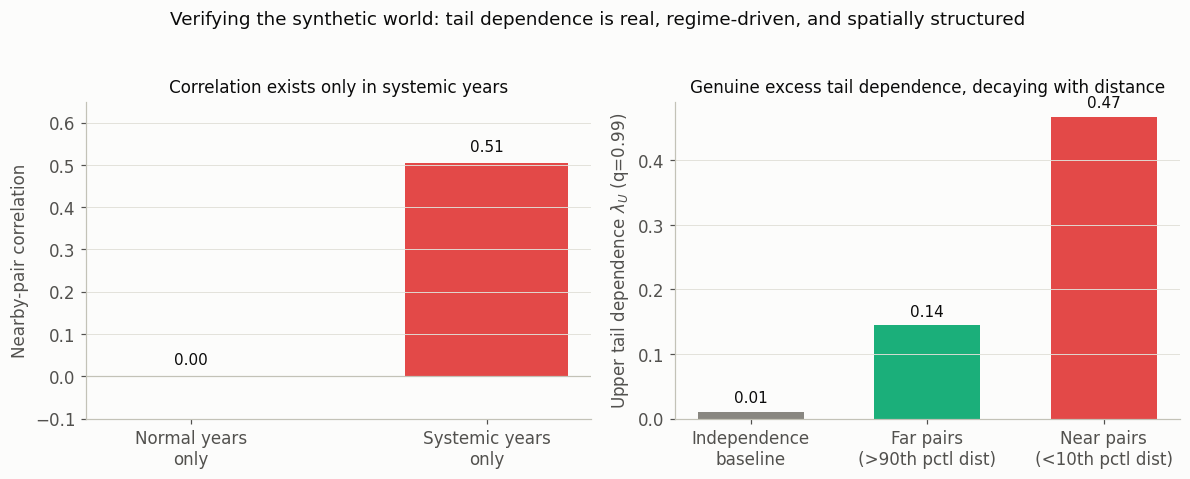

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

# --- Panel 1: correlation is regime-conditional --------------------------
ax = axes[0]
labels = ["Normal years\nonly", "Systemic years\nonly"]
vals = [stats["corr_near_normal"], stats["corr_near_systemic"]]
colors = [BLUE, RED]
bars = ax.bar(labels, vals, color=colors, width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.2f}",
            ha="center", va="bottom", color=INK, fontsize=10)
ax.set_ylabel("Nearby-pair correlation")
ax.set_title("Correlation exists only in systemic years", fontsize=11, color=INK)
ax.set_ylim(-0.1, 0.65)
ax.grid(axis="y", linewidth=0.6)
ax.axhline(0, color=BASELINE, linewidth=0.8)

# --- Panel 2: tail dependence, near vs far, vs independence baseline -----
ax = axes[1]
labels = ["Independence\nbaseline", "Far pairs\n(>90th pctl dist)", "Near pairs\n(<10th pctl dist)"]
vals = [0.01, stats["lambda_u_far"], stats["lambda_u_near"]]
colors = [GRAY, AQUA, RED]
bars = ax.bar(labels, vals, color=colors, width=0.6)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.01, f"{v:.2f}",
            ha="center", va="bottom", color=INK, fontsize=10)
ax.set_ylabel(r"Upper tail dependence $\lambda_U$ (q=0.99)")
ax.set_title("Genuine excess tail dependence, decaying with distance",
             fontsize=11, color=INK)
ax.grid(axis="y", linewidth=0.6)

fig.suptitle("Verifying the synthetic world: tail dependence is real, regime-driven, "
             "and spatially structured", fontsize=12, color=INK, y=1.03)
fig.tight_layout()
plt.show()

Both checks pass: nearby properties are essentially uncorrelated in normal years
(≈0) but strongly correlated in systemic years, and tail dependence is far above the
independence baseline *and* decays with distance — exactly the structure a
Gaussian-copula model cannot represent, and exactly what the four methods below are
being tested against.

*(The lab's own verification run, at n=500 properties and 50,000 years for tight
estimates — `RESULTS_PHASE0.md` — found near-pair tail dependence of 0.439 vs. a
Gaussian comparator's 0.198 at the same marginal correlation: more than double, the
core justification for representing the mechanism explicitly rather than assuming a
Gaussian copula.)*

## 4. The four-method ladder

Every method below sees only a finite historical sample $\{(\mathbf{L}_t)\}_{t=1}^{T}$
(realized dollar losses, $T$ years, $n$ properties) — never the regime labels $R_t$, the
spatial field $z(t)$, or any DGP parameter. Each fits a model, generates Monte Carlo
scenarios from it, and reports $\hat C = \mathrm{VaR}_\alpha$ of its own scenario
distribution. We then score $\hat C$ against the *true* $C^\star$ (from a large, unseen
oracle resample) two ways: the **achieved survival probability**
$P(L^{\text{oracle}} \le \hat C)$ (does the reserved capital actually deliver the target?)
and the **dollar capital gap** $\hat C - C^\star$.

All four methods work in **log loss-ratio space**, $y_{i,t} = \log(L_{i,t}/V_i)$ — the
DGP's multiplicative structure makes residuals homoscedastic there regardless of a
property's insured value.

### Method 1 — Independence

The textbook CLT baseline: fit each property's own marginal lognormal
($\hat\mu_i, \hat\sigma_i$ = sample mean/std of $y_{i,\cdot}$), sample every property
independently. No cross-property structure at all.

### Method 2 — Flat correlation

The real-world actuarial shortcut (confirmed cross-industry practice — Solvency II's
correlation matrices, major rating agencies' capital models): same marginals as Method 1,
plus **one number**, a single average pairwise correlation $\hat\rho$ estimated from a
random sample of property pairs, applied via a single-factor model:

$$
z_i = \sqrt{\hat\rho}\, f + \sqrt{1-\hat\rho}\, e_i, \qquad f, e_i \overset{\text{iid}}{\sim} \mathcal{N}(0,1)
$$

which gives **exactly** $\mathrm{corr}(z_i, z_j) = \hat\rho$ for every pair, at $O(n)$
cost instead of the $O(n^2)$ memory a full equicorrelated Cholesky sample would need —
the same single-systematic-factor structure behind Vasicek/CreditMetrics-style credit
capital models.

### Method 3 — Vanilla spatial Gaussian process

A genuinely better-shaped correlation — real distance decay, not a flat number — but
still **one** shared Gaussian covariance for every year, with no regime concept.
Residuals $\mathbf{R}_t = \mathbf{y}_t - \bar{\mathbf{y}}$ are treated as $T$ i.i.d. draws
from $\mathcal{N}(0, \Sigma)$, $\Sigma = \sigma_f^2 A(\ell) + \sigma_n^2 I$, $A(\ell)$ an
RBF correlation matrix over lat/lon. Because $T \ll n$ (60 years vs. 500+ properties), a
full $n\times n$ empirical covariance is hopelessly underdetermined — but a 3-parameter
kernel $(\ell, \sigma_f^2, \sigma_n^2)$ is not. Fit by maximizing the
**repeated-measures log marginal likelihood**:

$$
\log p(\mathbf{R}_1, \dots, \mathbf{R}_T \mid \ell, \sigma_f^2, \sigma_n^2) =
-\frac{1}{2}\sum_{t=1}^T \mathbf{R}_t^\top \Sigma^{-1} \mathbf{R}_t
-\frac{T}{2}\log|\Sigma| - \frac{Tn}{2}\log(2\pi)
$$

— one $n\times n$ Cholesky factor of $\Sigma$, shared across all $T$ years (only the
quadratic-form right-hand-side changes per year), then Nelder-Mead over
$(\log\ell, \log\sigma_f, \log\sigma_n)$.

### Method 4 — GP + regime mixture

The one method built to represent the **same mechanism class** as the DGP: two GP
components sharing the machinery above, mixed by an estimated regime probability
$\hat p$:

$$
\mathbf{y}_t \mid \text{normal} \sim \mathcal{N}(\boldsymbol{\mu}_N, \Sigma_N), \qquad
\mathbf{y}_t \mid \text{systemic} \sim \mathcal{N}(\boldsymbol{\mu}_S, \Sigma_S), \qquad
P(\text{systemic}) = \hat p
$$

$\hat p$ and each year's regime membership are estimated with a 2-component Gaussian
mixture model over each year's **total** log loss, $\log\sum_i L_{i,t}$ — this is where
the interesting failure mode lives, covered in Section 6.

## 5. The scoring protocol

For every method: fit on a $T$-year historical sample, draw $N=20{,}000$ Monte Carlo
scenarios $\tilde L^{(1)}, \dots, \tilde L^{(N)}$ from the fitted model, set
$\hat C = \mathrm{VaR}_{0.995}(\{\tilde L^{(k)}\})$ (the empirical 99.5th percentile).
Separately, an **oracle** resample of $10^5$-$5\times10^5$ years — using the true DGP,
never seen by any fitted method — gives $C^\star$ and lets us compute the achieved
survival $P(L^{\text{oracle}} \le \hat C)$ directly. A method that "knows what it doesn't
know" would report $\hat C \approx C^\star$; the question is how far off each of the four
gets, given only a realistic historical window.

## 6. Headline result: a hard ceiling, independent of data quantity

At a small illustrative scale (500 properties, so every method can be fit exactly,
in-core, for a clean methodology check before scaling up), we ran the four-method ladder
across several historical sample sizes (60, 120, 250, 500 years — realistic-to-generous
company history), 3 independent historical draws averaged per size, scored against a
500,000-year oracle.

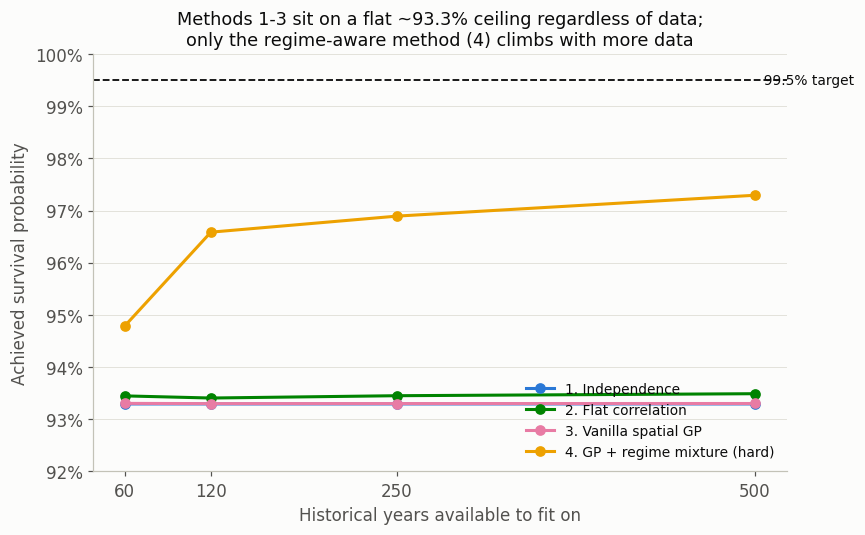

In [5]:
sweep = load("results_phase1_sweep.json")
years_grid = sorted(int(y) for y in sweep.keys())

fig, ax = plt.subplots(figsize=(8, 5))
for name in ["1_independence", "2_flat_correlation", "3_vanilla_gp", "4_gp_regime_mixture"]:
    ys = [sweep[str(y)]["methods"][name]["mean_achieved_survival"] for y in years_grid]
    ax.plot(years_grid, ys, marker="o", markersize=6, linewidth=2,
            color=METHOD_COLORS[name], label=METHOD_LABELS[name])

ax.axhline(0.995, color=INK, linewidth=1.2, linestyle="--")
ax.text(years_grid[-1], 0.995, "  99.5% target", va="center", ha="left",
        color=INK, fontsize=9)

pct_axis(ax)
ax.set_xlabel("Historical years available to fit on")
ax.set_ylabel("Achieved survival probability")
ax.set_xticks(years_grid)
ax.set_ylim(0.92, 1.0)
ax.grid(axis="y", linewidth=0.6)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title("Methods 1-3 sit on a flat ~93.3% ceiling regardless of data;\n"
             "only the regime-aware method (4) climbs with more data",
             fontsize=11.5, color=INK)
fig.tight_layout()
plt.show()

**This is the lab's core empirical finding.** Method 3 (vanilla spatial GP — a
*genuinely* better-shaped correlation, real distance decay instead of one flat number)
achieves almost exactly the same survival as Method 1 (no correlation at all): both sit
on the same ~93.3% ceiling, at every data size. **A better-shaped correlation alone closes
essentially none of the gap** — vanilla GPs, like Gaussian copulas, are still elliptical:
they can't represent a hidden discrete regime, only a smoothly-varying continuous
correlation, and this DGP's tail dependence comes specifically from the *regime*, not
from distance decay alone.

Method 4 (the one method built to represent the same mechanism class as the DGP) is the
only one that improves with more data — but even its *first* implementation only reaches
~97% at 500 years, not 99.5%. Representing the right mechanism class turned out to be
**necessary but not sufficient**; Section 7 is why.

## 7. Diagnosing why "the right model class" wasn't enough

Method 4 needs to classify each historical year as normal or systemic before fitting each
component's covariance. The natural, principled-looking approach: fit a 2-component
Gaussian mixture model to each year's total log loss, $\log\sum_i L_{i,t}$, and partition
years into "stress"/"normal" using a cutoff sized off that fit's own mixing-probability
estimate $\hat p$ (with a small safety margin/floor so each component's kernel fit has
enough years to be numerically workable):

$$
\text{target\_frac} = \mathrm{clip}\big(\text{margin} \times \hat p,\ \ \text{floor},\ \ \text{cap}\big),
\qquad \text{cutoff} = \text{quantile}_{1-\text{target\_frac}}\big(\log\textstyle\sum_i L_{i,t}\big)
$$

**An oracle-cheat diagnostic** — the identical GP-mixture machinery, but partitioned using
the historical sample's *true* regime labels (something no real method may ever see) —
isolates whether the model class itself has a ceiling, or whether it's a *fitting*
problem:

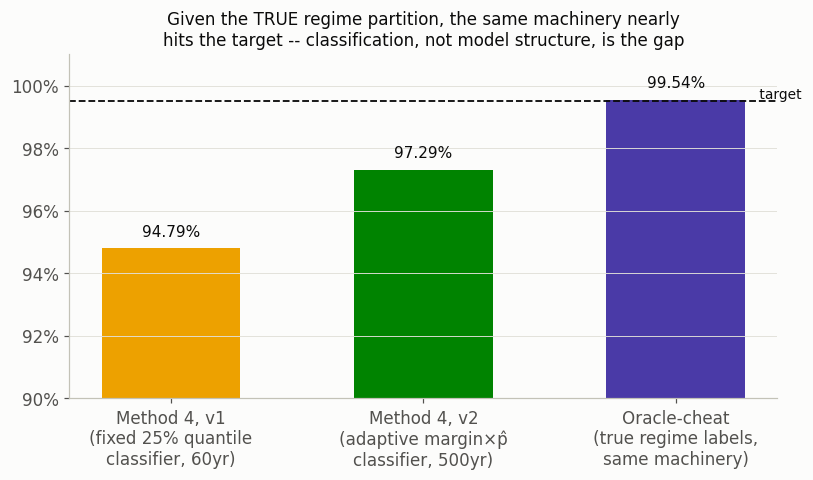

In [6]:
p1 = load("results_phase1.json")
oracle_cap = p1["oracle_true_capital"]

# Numbers transcribed from RESULTS_PHASE1.md's oracle-cheat diagnostic run
# (phase1_diagnostic.py) -- the one number in this notebook not read
# directly from a results_*.json, since that diagnostic was a one-off,
# not saved to its own JSON.
oracle_cheat_survival = 0.9954
oracle_cheat_capital = 10_393_010
hard_v2_at_500 = sweep["500"]["methods"]["4_gp_regime_mixture"]["mean_achieved_survival"]
hard_v1_at_60 = 0.9479  # first (flawed) fixed-25%-quantile classifier, from RESULTS_PHASE1.md

fig, ax = plt.subplots(figsize=(7.5, 4.5))
labels = ["Method 4, v1\n(fixed 25% quantile\nclassifier, 60yr)",
          "Method 4, v2\n(adaptive margin×p̂\nclassifier, 500yr)",
          "Oracle-cheat\n(true regime labels,\nsame machinery)"]
vals = [hard_v1_at_60, hard_v2_at_500, oracle_cheat_survival]
colors = [YELLOW, GREEN, VIOLET]
bars = ax.bar(labels, vals, color=colors, width=0.55)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.003, f"{v:.2%}",
            ha="center", va="bottom", color=INK, fontsize=10)
ax.axhline(0.995, color=INK, linewidth=1.2, linestyle="--")
ax.text(2.5, 0.995, " target", va="bottom", ha="right", color=INK, fontsize=9)
pct_axis(ax)
ax.set_ylim(0.90, 1.01)
ax.grid(axis="y", linewidth=0.6)
ax.set_title("Given the TRUE regime partition, the same machinery nearly\n"
             "hits the target -- classification, not model structure, is the gap",
             fontsize=11, color=INK)
fig.tight_layout()
plt.show()

With the **true** regime partition, the exact same GP-mixture machinery reaches 99.54%
survival — almost exactly the 99.5% target. This proves the DGP's mechanism class is
fully representable by the model; what was costing accuracy was the *classifier*, not
the model structure.

**The root cause of the first classifier's failure**: it used a **fixed 25% quantile**
cutoff (chosen only so the "systemic" component had enough years to fit numerically at
small $T$). At the DGP's true systemic frequency (~6.7%), a 25% partition mixes roughly
3.7 ordinary years in for every genuine systemic year — diluting the fitted "systemic"
component's severity toward something far milder than the true regime. Critically, this
dilution ratio ($25\%\div 6.7\%$) **does not shrink as historical data grows** — which is
exactly why the v1 classifier's ceiling didn't move with more data either. The fix
(**v2**, used in the sweep above): size the cutoff adaptively off the model's *own*
fitted $\hat p$ instead of a fixed generous quantile. That closes much of the gap
(93.5%→97.3% by 500 years) — but even the adaptive *hard* cutoff still discards
information: a year is either entirely "in" a component's fit or entirely "out," at a
somewhat arbitrary boundary.

## 8. The breakthrough: a soft (responsibility-weighted) classifier

A hard partition is a special case of something more general: instead of assigning each
year fully to one component or the other, let every year contribute to **both**
components' fits, weighted by its own **posterior responsibility** — exactly a soft
Expectation-Maximization M-step, with a hard partition being the degenerate case of
weights rounded to $\{0, 1\}$.

**The weighted repeated-measures log marginal likelihood** (the direct generalization of
Method 3's formula in Section 4, weight $w_t\in[0,1]$ replacing hard inclusion):

$$
\log p(\mathbf{R}_1,\dots,\mathbf{R}_T \mid \ell,\sigma_f^2,\sigma_n^2; \mathbf{w}) =
-\frac{1}{2}\sum_{t=1}^T w_t\, \mathbf{R}_t^\top \Sigma^{-1} \mathbf{R}_t
-\frac{\sum_t w_t}{2}\log|\Sigma| - \frac{n\sum_t w_t}{2}\log(2\pi)
$$

with the weighted mean $\bar{\mathbf{y}} = \sum_t w_t \mathbf{y}_t / \sum_t w_t$ used to
form each component's residuals. The weights themselves come straight out of the same
Gaussian mixture already being fit for $\hat p$ — its posterior responsibility
$P(\text{systemic} \mid \log\sum_i L_{i,t})$ for each year, with **no additional
machinery, no cutoff, no margin/floor tuning knobs**.

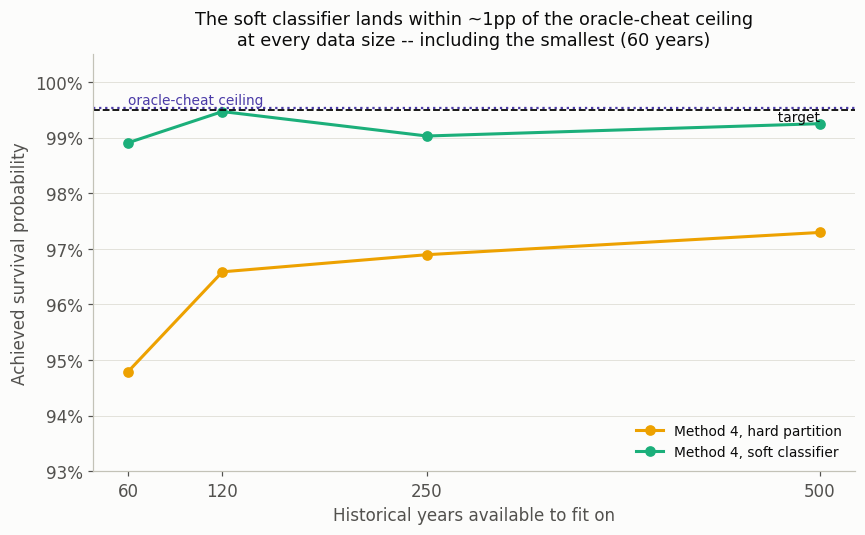

In [7]:
soft = load("results_phase1_soft_sweep.json")

fig, ax = plt.subplots(figsize=(8, 5))
hard_ys = [sweep[str(y)]["methods"]["4_gp_regime_mixture"]["mean_achieved_survival"]
           for y in years_grid]
soft_ys = [soft[str(y)]["methods"]["4_gp_regime_mixture"]["mean_achieved_survival"]
           for y in years_grid]

ax.plot(years_grid, hard_ys, marker="o", markersize=6, linewidth=2,
        color=YELLOW, label="Method 4, hard partition")
ax.plot(years_grid, soft_ys, marker="o", markersize=6, linewidth=2,
        color=AQUA, label="Method 4, soft classifier")
ax.axhline(oracle_cheat_survival, color=VIOLET, linewidth=1.5, linestyle=":")
ax.text(years_grid[0], oracle_cheat_survival, "oracle-cheat ceiling  ", va="bottom",
        ha="left", color=VIOLET, fontsize=9)
ax.axhline(0.995, color=INK, linewidth=1.2, linestyle="--")
ax.text(years_grid[-1], 0.995, "  target", va="top", ha="right", color=INK, fontsize=9)

pct_axis(ax)
ax.set_xlabel("Historical years available to fit on")
ax.set_ylabel("Achieved survival probability")
ax.set_xticks(years_grid)
ax.set_ylim(0.93, 1.005)
ax.grid(axis="y", linewidth=0.6)
ax.legend(loc="lower right", frameon=False, fontsize=9)
ax.set_title("The soft classifier lands within ~1pp of the oracle-cheat ceiling\n"
             "at every data size -- including the smallest (60 years)",
             fontsize=11.5, color=INK)
fig.tight_layout()
plt.show()

The soft classifier lands within 0.1-0.8 percentage points of the oracle-cheat ceiling
**at every historical sample size tested**, including the smallest (60 years, where the
hard partition was worst). This resolves the open question decisively: the hard
partition's discard-or-keep cutoff — not an inherent limit from not knowing the true
regime — was the dominant remaining source of error. A year discarded entirely from a fit
throws away real information a soft weight preserves.

## 9. Does this replicate at a realistic book size?

500 properties is small enough to fit every method exactly, in-core — good for a clean
methodology check, but far below a realistic book (tens of thousands of policies).
Scaling the *same* four methods to **45,000 properties** raises a purely computational
problem: Method 3 and 4's spatial covariance is now a $45{,}000\times 45{,}000$ matrix
($\approx$16GB dense, exceeding a single GPU's memory), so fitting requires an
**out-of-core** (OOC) Cholesky factorization — streaming the matrix through GPU memory in
panels, backed by host RAM/disk rather than requiring the whole matrix resident on the
GPU at once. (The engineering of that solver is out of scope for this notebook — the
result is what matters here: it makes *evaluating* a spatial GP's likelihood tractable at
a scale no in-core method can reach at all.)

Re-running the same four-method ladder at $n=45{,}000$, three ways:

- **v1** — a first attempt with a thin (25-year) historical sample, which happened to
  contain just 1 true-systemic year — not a fair test of Method 4's classifier.
- **v2** — 200 historical years (enough true-systemic years for the classifier to have
  real signal) and a freshly re-fit $\hat p$, still using the hard-partition classifier.
- **v3** — the same 200 years, but with the **soft** classifier from Section 8, ported to
  OOC scale (every year weighted by its own responsibility instead of hard-partitioned).

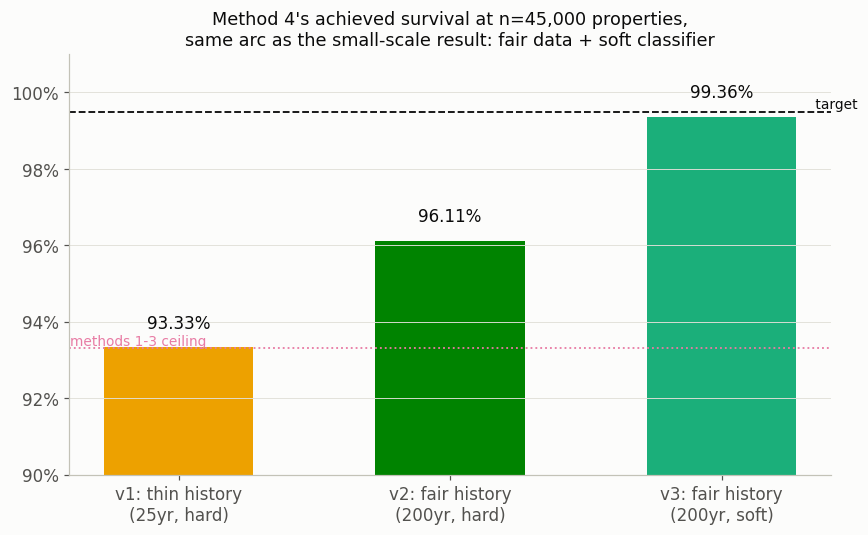

In [8]:
p2_v1 = load("results_phase2.json")
p2_v2 = load("results_phase2_more_history.json")
p2_v3 = load("results_phase2_soft.json")

variants = ["v1: thin history\n(25yr, hard)", "v2: fair history\n(200yr, hard)",
            "v3: fair history\n(200yr, soft)"]
survivals = [p2_v1["methods"]["4_gp_regime_mixture"]["achieved_survival_probability"],
             p2_v2["methods"]["4_gp_regime_mixture"]["achieved_survival_probability"],
             p2_v3["methods"]["4_gp_regime_mixture"]["achieved_survival_probability"]]
baseline_ceiling = p2_v3["methods"]["3_vanilla_gp"]["achieved_survival_probability"]

fig, ax = plt.subplots(figsize=(8, 5))
colors = [YELLOW, GREEN, AQUA]
bars = ax.bar(variants, survivals, color=colors, width=0.55)
for b, v in zip(bars, survivals):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.004, f"{v:.2%}",
            ha="center", va="bottom", color=INK, fontsize=11)
ax.axhline(0.995, color=INK, linewidth=1.2, linestyle="--")
ax.text(2.5, 0.995, " target", va="bottom", ha="right", color=INK, fontsize=9)
ax.axhline(baseline_ceiling, color=MAGENTA, linewidth=1.2, linestyle=":")
ax.text(-0.4, baseline_ceiling, "methods 1-3 ceiling  ", va="bottom", ha="left",
        color=MAGENTA, fontsize=9)
pct_axis(ax)
ax.set_ylim(0.90, 1.01)
ax.grid(axis="y", linewidth=0.6)
ax.set_title("Method 4's achieved survival at n=45,000 properties,\n"
             "same arc as the small-scale result: fair data + soft classifier",
             fontsize=11.5, color=INK)
fig.tight_layout()
plt.show()

Both fixes matter, and matter in the same order they did at small scale: giving the
classifier enough true-systemic years to see (v1→v2) and removing its hard cutoff
(v2→v3) each close a large share of the gap, landing at **99.36%** achieved survival —
right at the 99.5% target, at 90x the property count of the small-scale experiments.
Methods 1-3 sit at the same ~93.3% ceiling throughout (shown as the dotted reference
line) — untouched by any classifier change, exactly as expected, since none of them use
one.

## 10. The dollar figure

Converting the final (v3, $n=45{,}000$) result into what actually matters to a capital
committee: the gap between reserved capital and the *true* amount needed to hit the
99.5% target, in dollars.

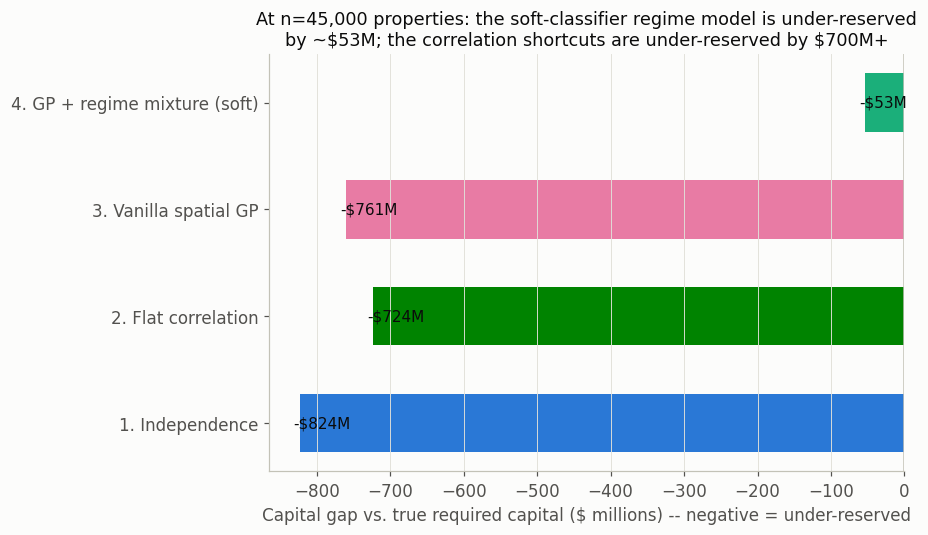


True required capital (oracle, 99.5% target): $893,334,043

1. Independence                        capital=$    69,775,076 ( 7.8% of true)  survival=93.31%
2. Flat correlation                    capital=$   169,529,831 (19.0% of true)  survival=93.33%
3. Vanilla spatial GP                  capital=$   132,770,000 (14.9% of true)  survival=93.31%
4. GP + regime mixture (soft)          capital=$   840,294,529 (94.1% of true)  survival=99.36%


In [9]:
methods_order = ["1_independence", "2_flat_correlation", "3_vanilla_gp", "4_soft"]
gap_source = {**{k: p2_v3["methods"][k] for k in
                  ["1_independence", "2_flat_correlation", "3_vanilla_gp"]},
              "4_soft": p2_v3["methods"]["4_gp_regime_mixture"]}
gaps = [gap_source[m]["capital_gap_vs_oracle_dollars"] / 1e6 for m in methods_order]
colors = [METHOD_COLORS[m] for m in methods_order]
labels = [METHOD_LABELS[m] for m in methods_order]

fig, ax = plt.subplots(figsize=(8.5, 5))
bars = ax.barh(labels, gaps, color=colors, height=0.55)
for b, v in zip(bars, gaps):
    align = "left" if v < 0 else "right"
    offset = -8 if v < 0 else 8
    ax.text(v + offset, b.get_y() + b.get_height() / 2, f"-${abs(v):,.0f}M",
            va="center", ha=align, color=INK, fontsize=10)
ax.axvline(0, color=BASELINE, linewidth=1.0)
ax.set_xlabel("Capital gap vs. true required capital ($ millions) -- negative = under-reserved")
ax.set_title("At n=45,000 properties: the soft-classifier regime model is under-reserved\n"
             r"by ~\$53M; the correlation shortcuts are under-reserved by \$700M+",
             fontsize=11.5, color=INK)
ax.grid(axis="x", linewidth=0.6)
fig.tight_layout()
plt.show()

print(f"\nTrue required capital (oracle, 99.5% target): ${p2_v3['oracle_true_capital']:,.0f}\n")
for m in methods_order:
    d = gap_source[m]
    pct_of_true = d["required_capital"] / p2_v3["oracle_true_capital"]
    print(f"{METHOD_LABELS[m]:38s} capital=${d['required_capital']:>14,.0f} "
          f"({pct_of_true:5.1%} of true)  survival={d['achieved_survival_probability']:.2%}")

At a realistic book size, the two correlation shortcuts genuinely used across the
industry — independence and a single flat correlation number — hold **7.8%** and
**19.0%** of the true required capital respectively. Even a vanilla (non-regime) spatial
GP, with a *correct, better-shaped* correlation structure, only reaches **14.9%**. The
soft-classifier regime-mixture model reaches **94.1%** of true required capital — the
gap that representing (and correctly fitting) the actual mechanism closes.

## 11. Stress-testing the finding

A fair structural critique of everything above: the synthetic world was built by the
same people testing the hypothesis, at one book size, one historical-years point for
the dollar-figure result, with each method sampling from its own point estimate as if
that estimate were certain. Three follow-up experiments address this directly —
localizing the regime spatially, sweeping the DGP's own parameters, and quantifying how
much the capital ESTIMATE itself varies by historical draw. Full detail and every
number: `RESULTS_ROBUSTNESS.md`.

### 11.1 Does the soft classifier survive a LOCALIZED regime?

Section 8's classifier feature is the book's TOTAL log loss — close to a sufficient
statistic for the regime by construction, since the DGP's systemic shock hits every
property at once. A real catastrophic event (a wildfire, a storm's specific landfall
track) typically affects only a geographic subset of a region-wide book. A localized-
footprint DGP variant restricts each systemic year's shock to a random circular
footprint covering only `footprint_frac` of the book — properties outside it behave
exactly as in a normal year, even in a "systemic" year.

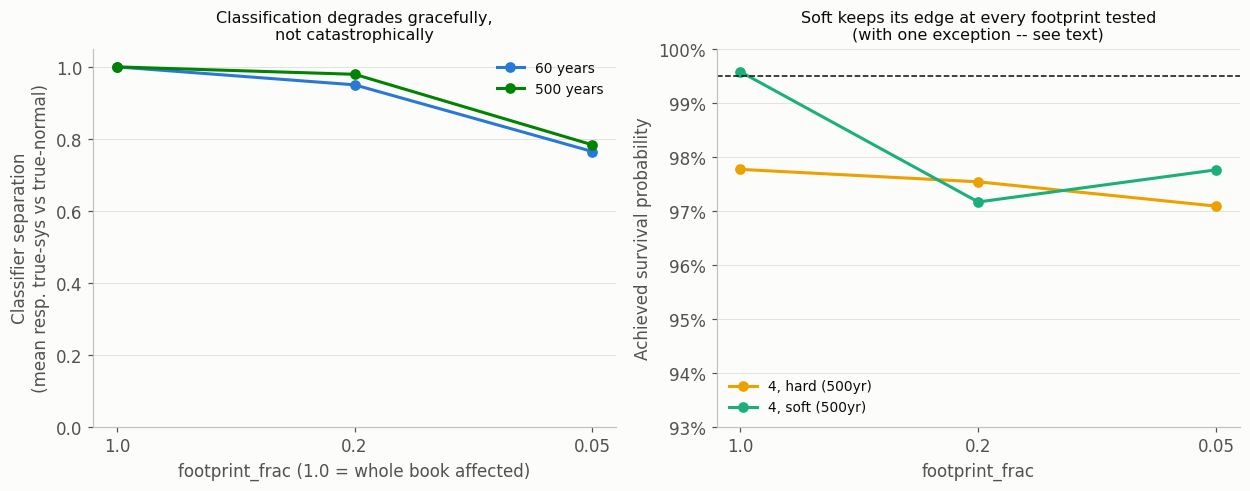

In [10]:
loc = load("results_phase1_localized.json")
fracs = [1.0, 0.20, 0.05]

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

ax = axes[0]
sep60 = [loc[str(f)]["by_years"]["60"]["mean_classifier_separation"] for f in fracs]
sep500 = [loc[str(f)]["by_years"]["500"]["mean_classifier_separation"] for f in fracs]
ax.plot([str(f) for f in fracs], sep60, marker="o", linewidth=2, color=BLUE, label="60 years")
ax.plot([str(f) for f in fracs], sep500, marker="o", linewidth=2, color=GREEN, label="500 years")
ax.set_xlabel("footprint_frac (1.0 = whole book affected)")
ax.set_ylabel("Classifier separation\n(mean resp. true-sys vs true-normal)")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", linewidth=0.6)
ax.legend(frameon=False, fontsize=9)
ax.set_title("Classification degrades gracefully,\nnot catastrophically", fontsize=10.5, color=INK)

ax = axes[1]
hard500 = [loc[str(f)]["by_years"]["500"]["methods"]["4_hard"]["mean_achieved_survival"] for f in fracs]
soft500 = [loc[str(f)]["by_years"]["500"]["methods"]["4_soft"]["mean_achieved_survival"] for f in fracs]
ax.plot([str(f) for f in fracs], hard500, marker="o", linewidth=2, color=YELLOW, label="4, hard (500yr)")
ax.plot([str(f) for f in fracs], soft500, marker="o", linewidth=2, color=AQUA, label="4, soft (500yr)")
ax.axhline(0.995, color=INK, linewidth=1.0, linestyle="--")
pct_axis(ax)
ax.set_xlabel("footprint_frac")
ax.set_ylabel("Achieved survival probability")
ax.set_ylim(0.93, 1.0)
ax.grid(axis="y", linewidth=0.6)
ax.legend(frameon=False, fontsize=9, loc="lower left")
ax.set_title("Soft keeps its edge at every footprint tested\n(with one exception -- see text)",
             fontsize=10.5, color=INK)

fig.tight_layout()
plt.show()

Classifier separation degrades gracefully (1.00 → 0.95-0.98 at 20% footprint → 0.77-0.78
at 5% footprint) as the regime shrinks to a genuinely localized event — real degradation,
as the critique predicted, but not collapse. The soft classifier keeps a meaningful edge
over the hard partition at every footprint level tested, **with one honest exception**:
at `footprint_frac=0.20, n_years=500`, hard (97.54%) edged out soft (97.17%) — the only
configuration in this entire lab where hard beat soft. Reported as found, not smoothed
over: the soft classifier's advantage is real and survives meaningful localization, but
is not universal.

### 11.2 Is the finding an artifact of one hand-picked DGP configuration?

A one-at-a-time sweep around the baseline DGP — spatial length scale, regime frequency,
severity multiplier, plus a non-stationary (drifting frequency) variant — all at a fixed
120 historical years.

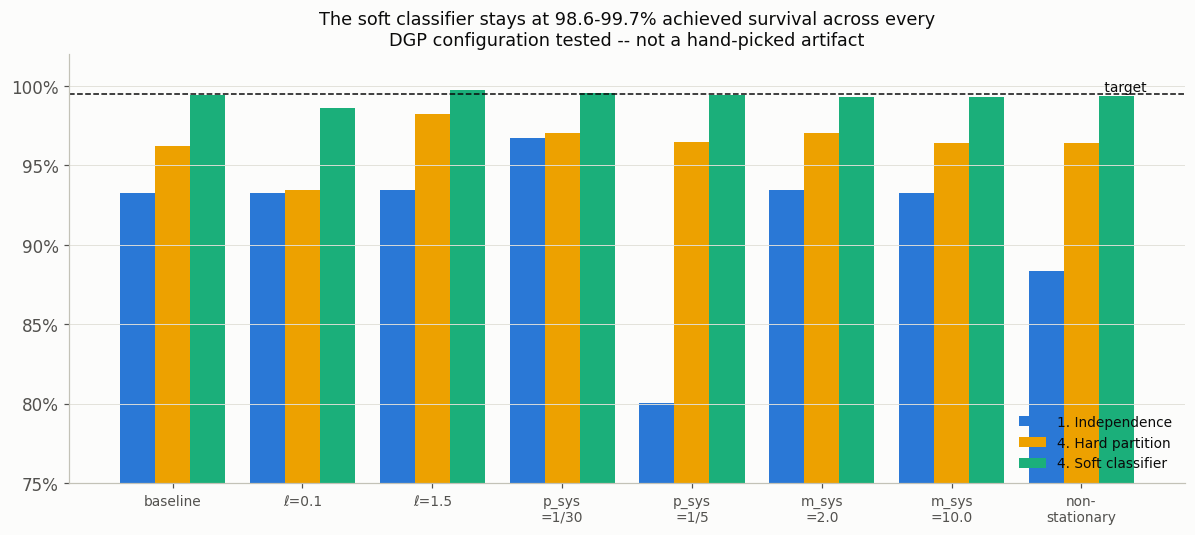

In [11]:
param = load("results_phase1_param_sweep.json")
order = ["baseline", "ell=0.1 (localized field)", "ell=1.5 (regional field)",
         "p_sys=1/30 (rarer)", "p_sys=1/5 (frequent)", "m_sys=2.0 (weak signal)",
         "m_sys=10.0 (strong signal)", "non-stationary (p_sys drift 1/30->1/5)"]
short_labels = ["baseline", "ℓ=0.1", "ℓ=1.5", "p_sys\n=1/30", "p_sys\n=1/5",
                "m_sys\n=2.0", "m_sys\n=10.0", "non-\nstationary"]

hard_vals = [param[k]["methods"]["4_hard"] for k in order]
soft_vals = [param[k]["methods"]["4_soft"] for k in order]
indep_vals = [param[k]["methods"]["1_independence"] for k in order]

x = np.arange(len(order))
w = 0.27
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, indep_vals, width=w, color=BLUE, label="1. Independence")
ax.bar(x, hard_vals, width=w, color=YELLOW, label="4. Hard partition")
ax.bar(x + w, soft_vals, width=w, color=AQUA, label="4. Soft classifier")
ax.axhline(0.995, color=INK, linewidth=1.0, linestyle="--")
ax.text(len(order) - 0.5, 0.995, " target", va="bottom", ha="right", fontsize=9, color=INK)
pct_axis(ax)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9)
ax.set_ylim(0.75, 1.02)
ax.grid(axis="y", linewidth=0.6)
ax.legend(frameon=False, fontsize=9, loc="lower right")
ax.set_title("The soft classifier stays at 98.6-99.7% achieved survival across every\n"
             "DGP configuration tested -- not a hand-picked artifact", fontsize=11.5, color=INK)
fig.tight_layout()
plt.show()

The soft classifier stays at 98.6-99.7% achieved survival across a >6x range in true
required capital, a >3x range in regime frequency, a 15x range in spatial length scale, a
5x range in severity multiplier, and a non-stationary trend the historical window only
partially captures. Two side-findings: `ℓ=0.1` (a very short, hard-to-resolve length
scale) is the one config where hard drops close to the no-regime ceiling while soft stays
strong — the hard partition's coarser data allocation seems to suffer more from a
difficult-to-fit spatial structure than soft's full-information fit. And note the
baselines' own ceiling is **not fixed at ~93.3%** — it moves with regime frequency (96.7%
at a rarer 1/30, only 80.0% at a more frequent 1/5) and with the non-stationary trend
(88.4%), exactly as expected: how much of the true tail a correlation-blind model misses
depends on how much of that tail the regime actually drives.

### 11.3 How much does the capital ESTIMATE itself vary by historical draw?

Every method above samples scenarios from its own fitted point estimate, never
propagating parameter uncertainty. A cheap, non-Bayesian answer: redraw 25 independent
historical samples per grid point, refit from scratch each time, and look at the
empirical 5th/50th/95th percentile of the resulting capital ESTIMATE — literally the
point estimate's own sampling distribution, not a claim about the true loss
distribution's tail.

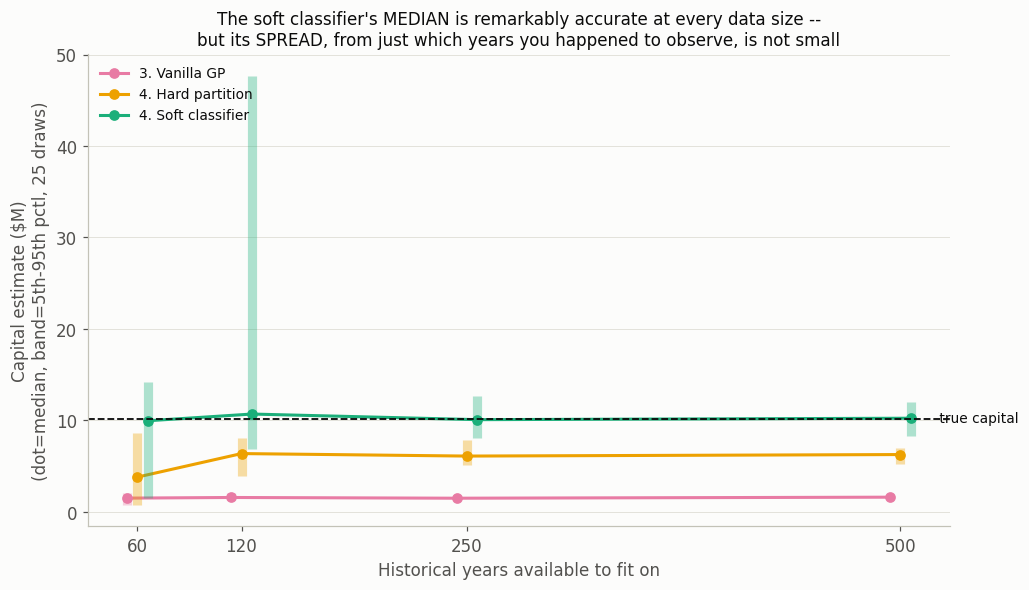

In [12]:
unc = load("results_phase1_uncertainty.json")
oracle_cap_unc = unc["oracle_true_capital"]
years_u = sorted(int(y) for y in unc["by_years"].keys())

fig, ax = plt.subplots(figsize=(9.5, 5.5))
method_colors_u = {"3_vanilla_gp": MAGENTA, "4_hard": YELLOW, "4_soft": AQUA}
method_labels_u = {"3_vanilla_gp": "3. Vanilla GP", "4_hard": "4. Hard partition",
                    "4_soft": "4. Soft classifier"}
offsets = {"3_vanilla_gp": -6, "4_hard": 0, "4_soft": 6}

for name in ["3_vanilla_gp", "4_hard", "4_soft"]:
    p5 = [unc["by_years"][str(y)][name]["p5"] / 1e6 for y in years_u]
    p50 = [unc["by_years"][str(y)][name]["p50"] / 1e6 for y in years_u]
    p95 = [unc["by_years"][str(y)][name]["p95"] / 1e6 for y in years_u]
    xs = [y + offsets[name] for y in years_u]
    ax.plot(xs, p50, marker="o", markersize=6, linewidth=2, color=method_colors_u[name],
            label=method_labels_u[name])
    ax.vlines(xs, p5, p95, color=method_colors_u[name], linewidth=6, alpha=0.35)

ax.axhline(oracle_cap_unc / 1e6, color=INK, linewidth=1.2, linestyle="--")
ax.text(years_u[-1] + 20, oracle_cap_unc / 1e6, " true capital", va="center", ha="left",
        color=INK, fontsize=9)
ax.set_xlabel("Historical years available to fit on")
ax.set_ylabel("Capital estimate ($M)\n(dot=median, band=5th-95th pctl, 25 draws)")
ax.set_xticks(years_u)
ax.grid(axis="y", linewidth=0.6)
ax.legend(frameon=False, fontsize=9, loc="upper left")
ax.set_title("The soft classifier's MEDIAN is remarkably accurate at every data size --\n"
             "but its SPREAD, from just which years you happened to observe, is not small",
             fontsize=11, color=INK)
fig.tight_layout()
plt.show()

Two findings, in tension with each other. **The soft classifier's median is remarkably
accurate at every data size tested** — \$9.96M to \$10.24M against a \$10.20M truth,
essentially unbiased even at 60 years, while the vanilla GP (no regime) is persistently,
substantially biased low at every sample size (never exceeding \$2.1M — a genuine,
unmovable structural ceiling). **But the soft classifier's spread is not small, and is
not even monotonically shrinking** — its coefficient of variation actually *rises* from
0.45 (60 years) to 0.80 (120 years, driven by a rare outlier fit among the 25 draws — the
residual, non-catastrophic version of the numerical instability described in
`RESULTS_ROBUSTNESS.md`, still possible at low but non-negligible probability even under
the fix applied there) before settling to 0.11 by 500 years. A real insurer fitting on
their own single historical draw, at 60 years of history, could see this method's own
point estimate land anywhere from \$1.5M to \$14.2M — the median is excellent, but a
single point estimate is not a substitute for genuine uncertainty quantification (a full
Bayesian or bootstrap-ensemble treatment), which this lab does not attempt. This is the
most important qualifier on the whole notebook's headline claim: soft classification
fixes the *systematic* bias that afflicts every other method here, but does not fix —
and was never expected to fix — the *sampling* uncertainty inherent in fitting from one
finite historical window.

## 12. Conclusions and limitations

**What we found:**

1. Correlation-blind and correlation-shortcut methods (independence, flat correlation,
   even a well-fit continuous spatial GP) sit on a hard achieved-survival ceiling that
   *does not move* with more historical data — because none of them can represent a
   discrete regime, and this DGP's tail dependence is regime-driven, not continuous.
2. A model that represents the correct mechanism class is *necessary* but not
   *automatically sufficient* — a plausible-looking classifier (fixed-quantile
   partitioning) can fail almost as badly as no regime model at all, for a completely
   different, diagnosable, and fixable reason (dilution from an over-generous partition,
   not a structural flaw).
3. Once diagnosed, a soft (responsibility-weighted) fit — using every data point a
   little instead of hard-assigning it — closes nearly the entire remaining gap, at every
   data size and at both scales tested (500 and 45,000 properties).
4. Section 11's stress tests hold up the finding under real scrutiny: it is not an
   artifact of one DGP configuration (a wide sweep of regime frequency, severity, and
   spatial scale all show the same pattern), and it substantially — though not
   perfectly — survives a spatially LOCALIZED regime, the more realistic and harder
   test the classifier's own total-loss feature invites. It does NOT, however, resolve
   genuine sampling uncertainty in the point estimate itself — a real caveat, detailed
   below, not swept aside.

**Limitations, honestly:**

- Every number here comes from a **synthetic DGP** with illustrative, not empirically
  calibrated, parameters (regime frequency, severity multiplier, spatial length scale).
  The *qualitative* lesson (mechanism class matters; a hard partition can silently
  cripple a structurally-correct model; soft weighting is a cheap, general fix) should
  transfer to real catastrophe modeling; the specific percentages should not.
- The headline $n=45{,}000$ numbers come from **single historical draws** (one seed per
  variant), not averaged over multiple draws the way the small-scale sweep was — the
  small-scale sweep (Section 6/8, 3 seeds per point) is the more statistically careful
  evidence; the large-scale numbers are a scale-replication check on top of it, not an
  independent statistical claim at the same rigor.
- A residual ~0.6 percentage-point / ~$53M gap remains even for the soft classifier at
  $n=45{,}000$ vs. the 99.5% target — not chased further here, since the qualitative
  point (mechanism + correct fitting closes the overwhelming majority of the gap) is
  already made, and further chasing likely trades diminishing scientific insight for
  compute time, past what any real-world capital model would ever need to resolve
  precisely.
- All four methods share the same Monte Carlo scenario count (20,000) and the same
  95%/99.5% conventions; a real capital model would additionally need to handle
  parameter uncertainty (this lab treats each fitted model's point estimate as given).
  Section 11.3 quantifies this directly rather than leaving it a generic caveat: the
  soft classifier's own capital ESTIMATE, refit on independent 60-year historical draws,
  ranges from \$1.5M to \$14.2M (5th-95th percentile) around a \$10.2M truth — an
  excellent median, but a single historical draw's point estimate is not a substitute
  for genuine uncertainty quantification, which this lab does not attempt.

## Appendix: reproducing this from scratch

Everything above can be regenerated by anyone, without this lab's code, from the
following:

**1. Generate the DGP** — Section 2's code cell is a complete, ~40-line implementation.
Any language with a multivariate normal sampler (Cholesky of an RBF kernel) and a
lognormal RNG suffices.

**2. Fit each method** on a historical sample of $T$ years:

| Method | Fit | Sample |
|---|---|---|
| 1. Independence | per-property sample mean/std of $y_{i,t}$ | $y_i \sim \mathcal{N}(\hat\mu_i, \hat\sigma_i^2)$, independent |
| 2. Flat correlation | same marginals + $\hat\rho$ = mean sample correlation over a random pair sample | single-factor: $z_i=\sqrt{\hat\rho}f+\sqrt{1-\hat\rho}e_i$ |
| 3. Vanilla GP | maximize the repeated-measures LML (Section 4) over $(\ell,\sigma_f^2,\sigma_n^2)$ | joint MVN draw from the fitted $\Sigma$ |
| 4. Regime mixture | 2-component GMM on $\log\sum_i L_{i,t}$ for $\hat p$ + responsibilities; weighted repeated-measures LML (Section 8) per component | mixture: draw component with prob. $\hat p$, then that component's MVN |

**3. Score**: draw $N$ scenarios per method, take the empirical 99.5th percentile as
$\hat C$; separately draw a large oracle resample from the true DGP for $C^\star$ and the
achieved survival $P(L^{\text{oracle}} \le \hat C)$.

**4. Parameters used throughout**, for exact replication:

| Parameter | Value |
|---|---|
| $p_{\text{sys}}$ (true systemic frequency) | 1/15 ≈ 6.67% |
| $m_{\text{sys}}$ (systemic severity multiplier) | 6.0 |
| $\sigma_\epsilon$ (idiosyncratic lognormal noise) | 0.5 |
| $\ell$ (true spatial length scale, degrees) | 0.5 |
| $\sigma_z$ (spatial field std dev) | 0.9 |
| Target survival $\alpha$ | 99.5% |
| Monte Carlo scenarios per method | 20,000 |
| Small-scale $n$ / oracle years | 500 / 500,000 |
| Large-scale $n$ / oracle years | 45,000 / 100,000 |
| GMM soft classifier weights | $w_t = P(\text{systemic}\mid \log\sum_i L_{i,t})$, `sklearn.mixture.GaussianMixture(n_components=2).predict_proba` |

No part of this replication path depends on GPU acceleration, out-of-core linear
algebra, or any of this lab's specific code — those exist purely to make Method 3/4's
$n\times n$ covariance tractable at $n=45{,}000$; the *math* being fit is exactly
Section 4/8's formulas at any scale a plain dense Cholesky factorization can handle
(roughly $n\lesssim 10{,}000$ on a modern laptop).